In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

np.random.seed(0)

In [21]:
# создаем 20 кошек и собак
X, y = [], []
for i in range(20):
    cat = np.zeros((20, 20))
    cat[7:15, 6:15] = 200          
    cat[3:7, 7:9] = 200             
    cat[3:7, 12:14] = 200            
    cat[10, 8] = 0; cat[10, 12] = 0
    cat = np.roll(cat, np.random.randint(-1, 1), axis=1) # сдвиг вбок
    cat = np.clip(cat + np.random.randint(0, 40, (20, 20))) # шум
    X.append(cat); y.append(0)
    
    dog = np.zeros((20, 20))
    dog[7:15, 6:15] = 200           
    dog[7:15, 1:5] = 200             
    dog[7:15, 16:20] = 200           
    dog[10, 8] = 0; dog[10, 12] = 0
    dog = np.roll(dog, np.random.randint(-1, 1), axis=1) # сдвиг вбок
    dog = np.clip(dog + np.random.randint(0, 40, (20, 20))) # шум
    X.append(dog); y.append(1)

X = np.array(X).reshape(40, 400)
y = np.array(y)

np.savez("homework_files/koshki_sobaki.npz", X=X, y=y) 
print(X.shape, y.shape)

(40, 400) (40,)


In [22]:
# делим обусение и проверку
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0)

In [23]:
# проверка качетсва
models = {
    "tree": DecisionTreeClassifier(random_state=0),
    "SVM": SVC(),
    "PCA+tree": make_pipeline(PCA(n_components=15), DecisionTreeClassifier(random_state=0)),
    "ansambl": RandomForestClassifier(random_state=0),
}
for name, m in models.items():
    m.fit(Xtr, ytr)
    print(name, round(m.score(Xte, yte), 2))

print(classification_report(yte, models["ansambl"].predict(Xte)))

tree 1.0
SVM 1.0
PCA+tree 1.0
ansambl 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [24]:
# атака одним пикселем
tree = DecisionTreeClassifier(random_state=0).fit(X, y) #обучаем
pred = tree.predict(X) # берем ответы

found = None
for i in range(40):
    if pred[i] != y[i]:
        continue #если уже есть ошибка, пропустим
    copya = X[i].copy()
    target = 1 - y[i]
    for j in range(400):
        for c in range(0, 255):
            if copya[j] == c:
                continue # не меняем если уже есть такое значение
            f = copya.copy()
            f[j] = c # меняем пиксель
            if tree.predict(f[None, :])[0] == target: # строку в таблицу
                found = (i, j, c)
                break
        if found:
            break
    if found:
        break

print("ready atak:", found)
print("str, stolbb:", found[1] // 20, found[1] % 20)

ready atak: (0, 201, 121)
str, stolbb: 10 1


Text(0.5, 1.0, 'dog')

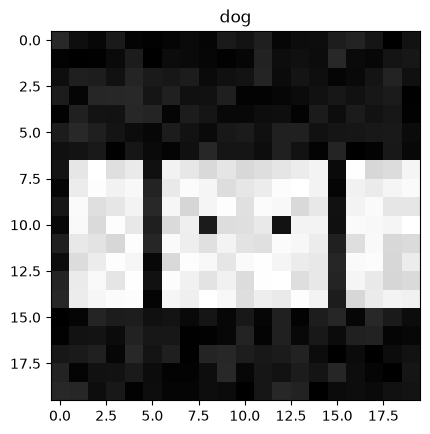

In [25]:
# показываем 
plt.imshow(X[-1].reshape(20, 20), cmap="gray"); plt.title("dog")

Text(0.5, 1.0, 'cat')

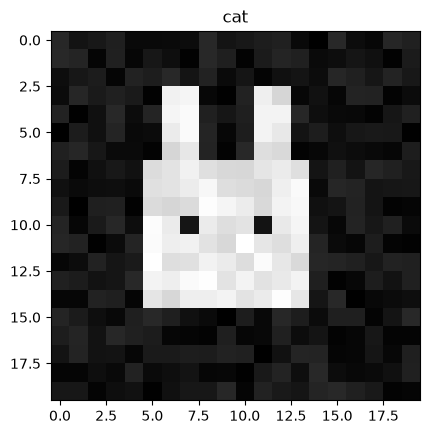

In [26]:
plt.imshow(X[0].reshape(20, 20), cmap="gray"); plt.title("cat")